# Setup

In [1]:
import os
import joblib
import torch
import pandas as pd
from ultralytics import YOLO
from nazi_symbols_classification.training.data_preparation import get_image_paths
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, roc_curve, auc


dir_name = os.path.dirname(os.getcwd())

# Classifier for nazi symbol detection

## Training
Train a model to determine whether a given image contains nazi symbols or not.

In [3]:
dataset_name = "nazi-symbols-detection-simple"
dataset_path = f"{dir_name}/datasets/{dataset_name}"

# Load a model
model = YOLO("yolo11s-cls.pt")  # load a pretrained model (recommended for training)

# Train the model
results = model.train(data=dataset_path, epochs=100, imgsz=224, patience=10)

New https://pypi.org/project/ultralytics/8.3.152 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.50 🚀 Python-3.12.3 torch-2.2.2+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 16068MiB)
engine/trainer: task=classify, mode=train, model=yolo11s-cls.pt, data=/home/zhiwei/Projects/nazi-symbols-classification/datasets/nazi-symbols-detection-simple, epochs=100, time=None, patience=10, batch=16, imgsz=224, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train14, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, ag

train: Scanning /mnt/data/nazi-symbols-classification/datasets/nazi-symbols-detection-simple/train... 77449 images, 0 corrupt: 100%|██████████| 77449/77449 [00:00<?, ?it/s]
val: Scanning /mnt/data/nazi-symbols-classification/datasets/nazi-symbols-detection-simple/val... 15274 images, 0 corrupt: 100%|██████████| 15274/15274 [00:00<?, ?it/s]


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 39 weight(decay=0.0), 40 weight(decay=0.0005), 40 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 224 train, 224 val
Using 8 dataloader workers
Logging results to /mnt/data/nazi-symbols-classification/runs/classify/train14
Starting training for 100 epochs...

      Epoch    GPU_mem       loss  Instances       Size


      1/100     0.967G    0.06598          9        224: 100%|██████████| 4841/4841 [04:58<00:00, 16.20it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 478/478 [00:25<00:00, 18.71it/s]

                   all      0.991          1


...

     11/100     0.967G     0.0512          9        224: 100%|██████████| 4841/4841 [03:50<00:00, 21.00it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 478/478 [00:24<00:00, 19.17it/s]

                   all      0.987          1


EarlyStopping: Training stopped early as no improvement observed in last 10 epochs. Best results observed at epoch 1, best model saved as best.pt.
To update EarlyStopping(patience=10) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

11 epochs completed in 0.843 hours.
Optimizer stripped from /mnt/data/nazi-symbols-classification/runs/classify/train14/weights/last.pt, 11.0MB
Optimizer stripped from /mnt/data/nazi-symbols-classification/runs/classify/train14/weights/best.pt, 11.0MB

Validating /mnt/data/nazi-symbols-classification/runs/classify/train14/weights/best.pt...
Ultralytics 8.3.50 🚀 Python-3.12.3 torch-2.2.2+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 16068MiB)
YOLO11s-cls summary (fused): 112 layers, 5,436,690 parameters, 0 gradients, 12.0 GFLOPs
train: /mnt/data/nazi-symbols-classification/datasets/nazi-symbols-detection-simple/train... found 77449 images in 2 classes ✅ 
val: /mnt/data/nazi-symbols-classification/datasets/nazi-symbols

               classes   top1_acc   top5_acc: 100%|██████████| 478/478 [00:26<00:00, 18.31it/s]


                   all      0.991          1
Speed: 0.1ms preprocess, 0.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /mnt/data/nazi-symbols-classification/runs/classify/train14


## Validation

In [2]:
model = YOLO(f"{dir_name}/runs/classify/train14/weights/best.pt")  # load a custom model

# Validate the model
metrics = model.val()  # no arguments needed, dataset and settings remembered

Ultralytics 8.3.50 🚀 Python-3.12.3 torch-2.2.2+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 16068MiB)
YOLO11s-cls summary (fused): 112 layers, 5,436,690 parameters, 0 gradients, 12.0 GFLOPs
train: /mnt/data/nazi-symbols-classification/datasets/nazi-symbols-detection/train... found 75369 images in 2 classes ✅ 
val: /mnt/data/nazi-symbols-classification/datasets/nazi-symbols-detection/val... found 15376 images in 2 classes ✅ 
test: /mnt/data/nazi-symbols-classification/datasets/nazi-symbols-detection/test... found 15018 images in 2 classes ✅ 


val: Scanning /mnt/data/nazi-symbols-classification/datasets/nazi-symbols-detection/val... 15376 images, 0 corrupt: 100%|██████████| 15376/15376 [00:00<?, ?it/s]
libpng warning: iCCP: known incorrect sRGB profile|███▋      | 353/961 [00:21<00:34, 17.86it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 961/961 [00:55<00:00, 17.34it/s]


                   all      0.996          1
Speed: 0.6ms preprocess, 2.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /mnt/data/nazi-symbols-classification/runs/classify/val4


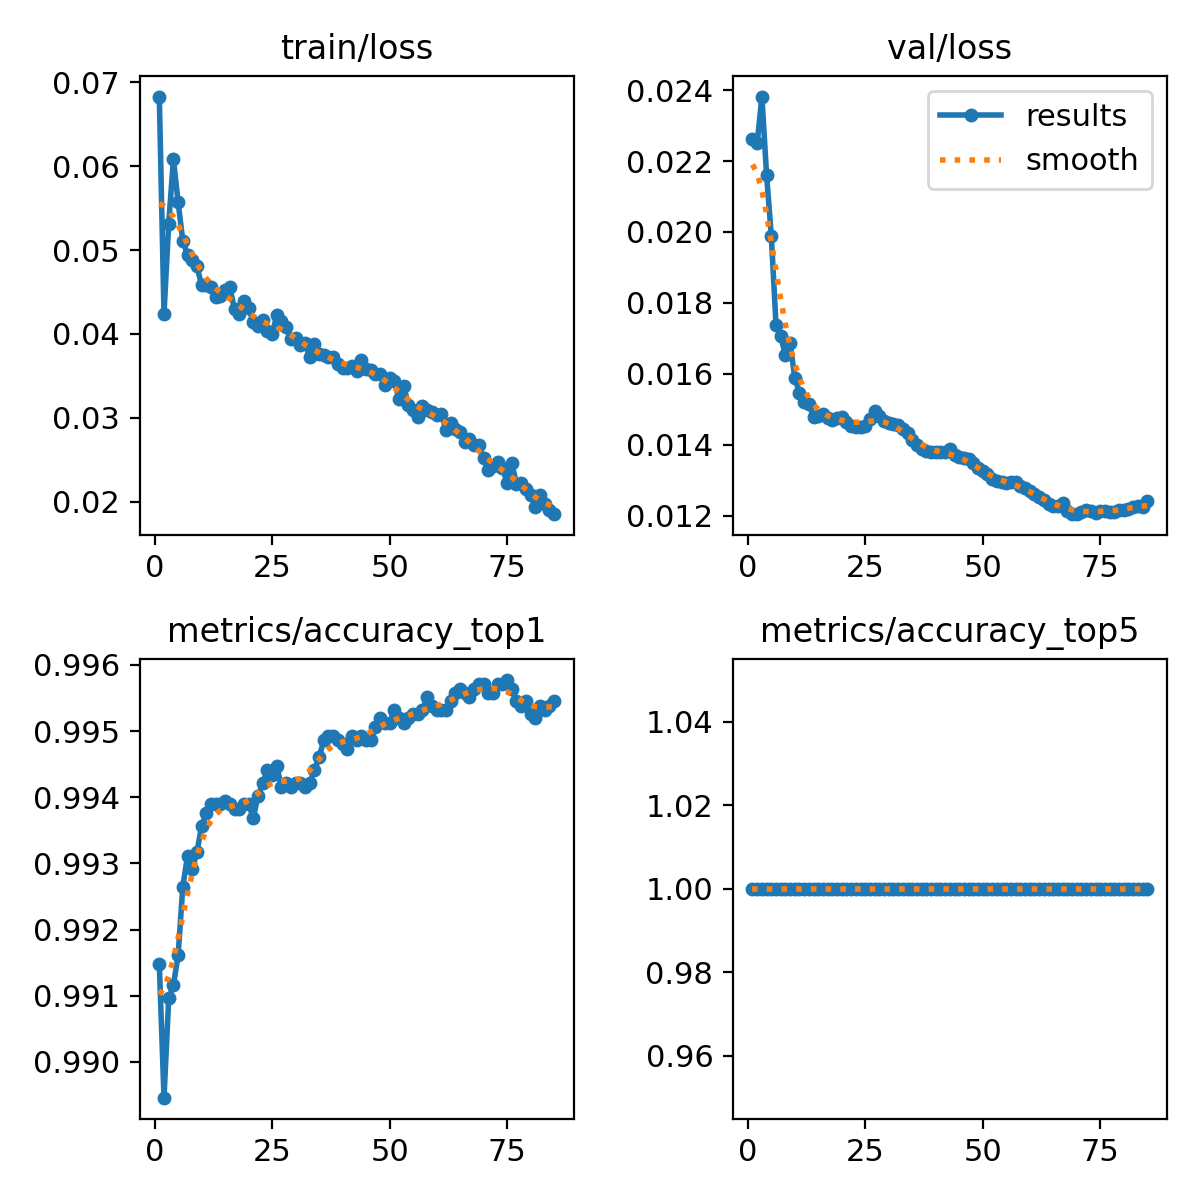

In [4]:
from IPython.display import Image

Image(filename=f"{dir_name}/runs/classify/train8/results.png", width=1000)  # view results.png

## Model Evaluation

### Prepare datasets

In [2]:
images = get_image_paths(f"{dir_name}/datasets/nazi-symbols-detection-simple", 
                         ("train", "test", "val"))

In [3]:
train_images = [image for image in images if image.startswith(f"{dir_name}/datasets/nazi-symbols-detection-simple/train")]
test_images = [image for image in images if image.startswith(f"{dir_name}/datasets/nazi-symbols-detection-simple/test")]
valid_images = [image for image in images if image.startswith(f"{dir_name}/datasets/nazi-symbols-detection-simple/val")]

In [4]:
y_test = [os.path.basename(os.path.dirname(image)) for image in test_images]
y_test.count("nazi-symbol"), y_test.count("non-nazi")

(148, 14813)

### Evaluate the model

In [5]:
model = YOLO(f"{dir_name}/runs/classify/train14/weights/best.pt")

In [6]:
outputs = []
probs = []
step = 50
for i in range(0, len(test_images), step):
    with torch.no_grad():
        predicted_results = model(source=test_images[i:i+step], stream=False)
    for pr in predicted_results:
        pr = pr.cpu()
        label = model.names[pr.probs.top1]
        outputs.append(label)
        probs.append(pr.probs.top1conf.item())


0: 224x224 non-nazi 0.97, nazi-symbol 0.03, 1.2ms
1: 224x224 non-nazi 1.00, nazi-symbol 0.00, 1.2ms
2: 224x224 non-nazi 0.99, nazi-symbol 0.01, 1.2ms
3: 224x224 non-nazi 0.52, nazi-symbol 0.48, 1.2ms
4: 224x224 non-nazi 1.00, nazi-symbol 0.00, 1.2ms
5: 224x224 non-nazi 1.00, nazi-symbol 0.00, 1.2ms
6: 224x224 non-nazi 1.00, nazi-symbol 0.00, 1.2ms
7: 224x224 non-nazi 1.00, nazi-symbol 0.00, 1.2ms
8: 224x224 non-nazi 1.00, nazi-symbol 0.00, 1.2ms
9: 224x224 non-nazi 0.92, nazi-symbol 0.08, 1.2ms
10: 224x224 non-nazi 0.99, nazi-symbol 0.01, 1.2ms
11: 224x224 nazi-symbol 0.93, non-nazi 0.07, 1.2ms
12: 224x224 non-nazi 1.00, nazi-symbol 0.00, 1.2ms
13: 224x224 non-nazi 0.99, nazi-symbol 0.01, 1.2ms
14: 224x224 non-nazi 1.00, nazi-symbol 0.00, 1.2ms
15: 224x224 non-nazi 0.98, nazi-symbol 0.02, 1.2ms
16: 224x224 non-nazi 0.99, nazi-symbol 0.01, 1.2ms
17: 224x224 non-nazi 1.00, nazi-symbol 0.00, 1.2ms
18: 224x224 non-nazi 0.89, nazi-symbol 0.11, 1.2ms
19: 224x224 non-nazi 0.96, nazi-symbol 0

In [7]:
len(probs), outputs[:3], probs[:3], y_test[:3]

(14961,
 ['non-nazi', 'non-nazi', 'non-nazi'],
 [0.972301721572876, 0.9986448884010315, 0.9937092065811157],
 ['non-nazi', 'non-nazi', 'non-nazi'])

In [8]:
outputs_tmp = [int(item == 'nazi-symbol') for item in outputs]
y_test_tmp = [int(item == 'nazi-symbol') for item in y_test]
len(probs), outputs_tmp[:3], probs[:3], y_test_tmp[:3]

(14961,
 [0, 0, 0],
 [0.972301721572876, 0.9986448884010315, 0.9937092065811157],
 [0, 0, 0])

### Calculate metrics

In [10]:
fpr, tpr, threshold = roc_curve(y_test_tmp, probs)
roc_auc = auc(fpr, tpr)
roc_auc_result = dict(fpr=fpr, tpr=tpr, threshold=threshold, roc_auc=roc_auc)

print(classification_report(y_test_tmp, outputs_tmp, digits=3))
print("accuracy score:", accuracy_score(y_test_tmp, outputs_tmp))
print("roc auc score:", roc_auc_score(y_test_tmp, outputs_tmp))

              precision    recall  f1-score   support

           0      0.996     0.999     0.997     14813
           1      0.792     0.568     0.661       148

    accuracy                          0.994     14961
   macro avg      0.894     0.783     0.829     14961
weighted avg      0.994     0.994     0.994     14961

accuracy score: 0.994251721141635
roc auc score: 0.7830411928163903


In [11]:
joblib.dump(roc_auc_result, 'yolo-output/YOLO-binary-simple-roc-auc-results.joblib')

['yolo-output/YOLO-binary-simple-roc-auc-results.joblib']